# Task
Develop a Nigerian food recommendation system using the provided dataset to address a real-world problem, focusing on innovation, relevance, and adherence to industry standards. The solution should include data analysis, model development, evaluation, and a discussion of deployment and compliance.

## Data loading and initial exploration

### Subtask:
Load the Nigerian food dataset and perform initial exploration to understand its structure, features, and potential insights.


**Reasoning**:
Load the dataset into a pandas DataFrame and perform initial exploration steps as requested.



In [ ]:
import pandas as pd
import os

# Install Kaggle library
!pip install kaggle -q

# Create a directory for Kaggle credentials
!mkdir ~/.kaggle

# Create a dummy kaggle.json file (will be replaced by user input)
# This is a placeholder and the user will be prompted to upload their kaggle.json file.
# The user needs to get their API key from Kaggle (Account -> API -> Create New API Token)
# and upload the downloaded kaggle.json file when prompted.
kaggle_config_path = os.path.join(os.path.expanduser("~"), ".kaggle", "kaggle.json")
if not os.path.exists(kaggle_config_path):
    # Create a dummy file if it doesn't exist to avoid errors in subsequent commands
    with open(kaggle_config_path, 'w') as f:
        f.write('{"username":"YOUR_KAGGLE_USERNAME","key":"YOUR_KAGGLE_API_KEY"}')

# Copy the kaggle.json file to the created directory
# The user will be prompted to upload their actual kaggle.json file here.
# Once uploaded, it will overwrite the dummy file.
# You can get your kaggle.json file from your Kaggle account settings under 'API'.
from google.colab import files
print("Please upload your kaggle.json file:")
files.upload()


# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset from Kaggle
# The dataset is located at https://www.kaggle.com/datasets/franklycypher/nigerian-foods
# The command to download is 'kaggle datasets download -d <dataset-slug>'
# The dataset slug is 'franklycypher/nigerian-foods'
!kaggle datasets download -d franklycypher/nigerian-foods

# Unzip the downloaded dataset
# The downloaded file is a zip file, usually named after the dataset slug.
# Let's assume the zip file is named 'nigerian-foods.zip'
!unzip nigerian-foods.zip

# Load the dataset (assuming the unzipped file is named 'Nigerian Foods.csv' with a space)
# If the unzipped file has a different name, this will need to be adjusted.
# We can check the unzipped files to confirm the name if needed.
try:
    df = pd.read_csv('Nigerian Foods.csv')
except FileNotFoundError:
    print("Error: 'Nigerian Foods.csv' not found after unzipping. Please check the extracted file names.")
    # List files in the current directory to help identify the correct file name
    !ls


# Display the first 5 rows
display(df.head())

# Print column names and their data types
print(df.columns)
print(df.dtypes)

# Get a concise summary of the DataFrame
df.info()

# Generate descriptive statistics for numerical columns
display(df.describe())

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Please upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/franklycypher/nigerian-foods
License(s): apache-2.0
nigerian-foods.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  nigerian-foods.zip
replace Nigerian Foods.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: Nigerian Foods.csv      


,Food_Name,Main_Ingredients,Description,Food_Health,Food_Class,Region,Spice_Level,Price_Range
0,Abacha,"African salad, utazi leaves, oil, fish",Cassava-based salad with spicy fish,Healthy,Traditional,South-East,Spicy,Affordable
1,Abacha and Ugba (Regular),"Abacha (Cassava Fufu), Ugba (Oilbean Seeds)",Shredded cassava fufu served with oilbean seeds.,Healthy,Traditional,Eastern,NaN,Affordable
2,Abacha and Ugba,"African salad, oil, fish, fermented oil bean s...",Cassava-based salad with spicy fish and fermen...,Healthy,Salad,South-East,Spicy,Affordable
3,Afang Soup (Spicy),"Afang Leaves, Water yam, Seafood","Spicy soup made with afang leaves, water yam, ...",Healthy,Traditional,Southern,Spicy,Affordable
4,Afang Soup,"Afang leaves, waterleaf, meat, fish",Nutritious soup made with wild spinach and wat...,Healthy,Traditional,South-South,Mild,Affordable


Index(['Food_Name', 'Main_Ingredients', 'Description', 'Food_Health',
       'Food_Class', 'Region', 'Spice_Level', 'Price_Range'],
      dtype='object')
Food_Name           object
Main_Ingredients    object
Description         object
Food_Health         object
Food_Class          object
Region              object
Spice_Level         object
Price_Range         object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Food_Name         109 non-null    object
 1   Main_Ingredients  109 non-null    object
 2   Description       109 non-null    object
 3   Food_Health       109 non-null    object
 4   Food_Class        109 non-null    object
 5   Region            109 non-null    object
 6   Spice_Level       94 non-null     object
 7   Price_Range       109 non-null    object
dtypes: object(8)
memory usage: 6.9+ KB


,Food_Name,Main_Ingredients,Description,Food_Health,Food_Class,Region,Spice_Level,Price_Range
count,109,109,109,109,109,109,94,109
unique,109,108,109,5,14,12,6,5
top,Abacha,"Flour, yeast, sugar, eggs",Cassava-based salad with spicy fish,Healthy,Traditional,Nationwide,Mild,Affordable
freq,1,2,1,64,51,34,46,71


In [ ]:
# Perform one-hot encoding on categorical features
categorical_features = ['Food_Health', 'Food_Class', 'Region', 'Spice_Level', 'Price_Range']
df_encoded = pd.get_dummies(df, columns=categorical_features)

# Display the first few rows of the encoded DataFrame
display(df_encoded.head())

# Print the columns of the encoded DataFrame to see the new features
print(df_encoded.columns)

,Food_Name,Main_Ingredients,Description,Food_Health_Healthy,Food_Health_Healthy (varies),Food_Health_Moderately Healthy,Food_Health_Non-Healthy,Food_Health_Not Healthy,Food_Class_Beverage,Food_Class_Bread,...,Spice_Level_Mild - Spicy,Spice_Level_None - Mild,Spice_Level_Spicy,Spice_Level_Unknown,Spice_Level_Varies,Price_Range_Affordable,Price_Range_Expensive,Price_Range_Moderate,Price_Range_Moderate-Expensive,Price_Range_Very Expensive
0,Abacha,"African salad, utazi leaves, oil, fish",Cassava-based salad with spicy fish,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,Abacha and Ugba (Regular),"Abacha (Cassava Fufu), Ugba (Oilbean Seeds)",Shredded cassava fufu served with oilbean seeds.,True,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2,Abacha and Ugba,"African salad, oil, fish, fermented oil bean s...",Cassava-based salad with spicy fish and fermen...,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
3,Afang Soup (Spicy),"Afang Leaves, Water yam, Seafood","Spicy soup made with afang leaves, water yam, ...",True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
4,Afang Soup,"Afang leaves, waterleaf, meat, fish",Nutritious soup made with wild spinach and wat...,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


Index(['Food_Name', 'Main_Ingredients', 'Description', 'Food_Health_Healthy',
       'Food_Health_Healthy (varies)', 'Food_Health_Moderately Healthy',
       'Food_Health_Non-Healthy', 'Food_Health_Not Healthy',
       'Food_Class_Beverage', 'Food_Class_Bread', 'Food_Class_Breakfast',
       'Food_Class_Combo', 'Food_Class_Dessert', 'Food_Class_Dish',
       'Food_Class_Modern', 'Food_Class_Salad', 'Food_Class_Side Dish',
       'Food_Class_Snack', 'Food_Class_Soup', 'Food_Class_Stew',
       'Food_Class_Swallow', 'Food_Class_Traditional', 'Region_Eastern',
       'Region_Lagos', 'Region_Nationwide', 'Region_North', 'Region_Northern',
       'Region_South', 'Region_South-East', 'Region_South-South',
       'Region_South-West', 'Region_Southern', 'Region_Southwestern',
       'Region_West', 'Spice_Level_Medium', 'Spice_Level_Mild',
       'Spice_Level_Mild - Spicy', 'Spice_Level_None - Mild',
       'Spice_Level_Spicy', 'Spice_Level_Unknown', 'Spice_Level_Varies',
       'Price_Range_Af

## Data Preprocessing and Feature Engineering

### Subtask:
Clean the data, handle missing values, and engineer relevant features for the recommendation model.

In [6]:
# Handle missing values in 'Spice_Level' by filling with 'Unknown'.
df['Spice_Level'] = df['Spice_Level'].fillna('Unknown')

# Verify that missing values are handled
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Food_Name         109 non-null    object
 1   Main_Ingredients  109 non-null    object
 2   Description       109 non-null    object
 3   Food_Health       109 non-null    object
 4   Food_Class        109 non-null    object
 5   Region            109 non-null    object
 6   Spice_Level       109 non-null    object
 7   Price_Range       109 non-null    object
dtypes: object(8)
memory usage: 6.9+ KB
None


## Feature Engineering from Text Data

### Subtask:
Extract numerical features from the 'Main_Ingredients' and 'Description' columns using techniques like TF-IDF.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine the text from 'Main_Ingredients' and 'Description' for TF-IDF
df['text_features'] = df['Main_Ingredients'] + ' ' + df['Description']

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Fit and transform the text data
tfidf_matrix = tfidf.fit_transform(df['text_features'])

# Convert the TF-IDF matrix to a DataFrame for easier handling
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=df.index, columns=tfidf.get_feature_names_out())

# Display the shape of the TF-IDF DataFrame
print("Shape of TF-IDF DataFrame:", tfidf_df.shape)

# Display the first few rows of the TF-IDF DataFrame (optional, as it can be large)
# display(tfidf_df.head())

Shape of TF-IDF DataFrame: (109, 274)


## Deployment

### Subtask:
Discuss potential deployment strategies for the recommendation system.

**Deployment Considerations:**

Deploying a content-based recommendation system like this involves making the recommendation function accessible and scalable within a larger application. Here are some considerations:

1.  **API Endpoint**: The recommendation logic (the `get_recommendations` function) can be exposed as an API endpoint. When a user requests recommendations for a specific food item, the application can call this API with the food name.

2.  **Frameworks**: Popular web frameworks like Flask or Django (in Python) or others in different languages can be used to build the API. These frameworks handle request routing, data serialization (e.g., converting the recommendations DataFrame to JSON), and response handling.

3.  **Containerization**: Packaging the application and its dependencies using technologies like Docker ensures consistency across different environments and simplifies deployment.

4.  **Cloud Platforms**: Deploying the containerized application on cloud platforms like Google Cloud Platform (GCP), Amazon Web Services (AWS), or Microsoft Azure provides scalability, reliability, and managed services.

5.  **Database**: The original food dataset and potentially the pre-calculated similarity matrix could be stored in a database (e.g., PostgreSQL, MySQL, or a NoSQL database). The API would query this database to retrieve necessary data for generating recommendations.

6.  **Caching**: To improve performance, especially for frequently requested recommendations, caching mechanisms (e.g., Redis or Memcached) can be implemented to store recommendation results temporarily.

7.  **Scalability**: The deployment architecture should be designed to handle an increasing number of users and requests. This might involve using load balancers, auto-scaling groups, and optimizing database queries.

8.  **Real-time vs. Batch Processing**: Recommendations can be generated in real-time when a user requests them, or they can be pre-calculated in batches (e.g., daily or hourly) and stored for faster retrieval. The choice depends on the required freshness of recommendations and computational resources.

9.  **Monitoring and Logging**: Implement monitoring to track API performance, errors, and usage. Logging helps in debugging and understanding system behavior.

**Integration with a Food Delivery App:**

Within a Nigerian food delivery app, the deployed recommendation system could be integrated in several ways:

*   **Homepage Recommendations**: Display a "Recommended for You" section on the app's home screen based on the user's past interactions (if available) or popular food items.
*   **Food Detail Page**: When a user views a specific food item, show a list of "Similar Foods" or "Other users who liked this also liked..." based on the content-based similarity.
*   **Search and Filtering**: Enhance search results and filtering options with recommendations based on selected criteria.

The choice of deployment strategy and integration points would depend on the specific requirements, scale, and existing infrastructure of the food delivery application.

## Model Evaluation

### Subtask:
Discuss how to evaluate the performance of the content-based recommendation model.

**Evaluation Approaches for Content-Based Systems (without user data):**

Since this is a content-based recommendation system and we lack explicit user interaction data (ratings, clicks, etc.), traditional evaluation metrics like RMSE, Precision, or Recall (commonly used in collaborative filtering) are not directly applicable. However, we can still evaluate the model's performance through other means:

1.  **Qualitative Evaluation**:
    *   **Manual Inspection**: The most straightforward approach is to manually inspect the recommendations generated for various food items. Do the recommendations seem relevant and sensible based on the 'Main_Ingredients', 'Description', 'Food_Health', 'Food_Class', 'Region', 'Spice_Level', and 'Price_Range' features?
    *   **Expert Review**: Have domain experts (e.g., people familiar with Nigerian cuisine) review the recommendations and provide feedback on their quality and relevance.

2.  **Proxy Metrics**:
    *   **Diversity**: While recommendations should be similar to the input item, recommending items that are too similar might not be helpful. We can evaluate the diversity of the top-N recommendations to ensure variety. Metrics like the average pairwise distance between recommended items in the feature space can be used.
    *   **Serendipity**: Does the system recommend items that are relevant but unexpected? This is harder to measure without user feedback, but in a live system, tracking whether users interact with unexpected recommendations could be a proxy.

3.  **Offline Simulation (if historical data were available)**:
    *   If we had historical data on what food items users viewed or ordered together, we could simulate the recommendation process offline and compare the model's recommendations to actual user behavior.

**Limitations of Current Evaluation**:

Given the current dataset and lack of user interaction data, a rigorous quantitative evaluation of the recommendation model's effectiveness in terms of predicting user preference is not possible. The evaluation will primarily rely on qualitative assessment of the recommendation relevance based on the food item features.

**Future Evaluation (with user data)**:

If this system were to be deployed in a real application, we would collect user interaction data (clicks, views, orders, ratings) and use A/B testing to compare the recommendation system's performance against a baseline or other recommendation strategies. Metrics like click-through rate, conversion rate, average order value, and user retention could then be used for evaluation.

/tmp/ipython-input-747122342.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Similarity_Score', y='Food_Name', data=recommended_foods, palette='viridis')


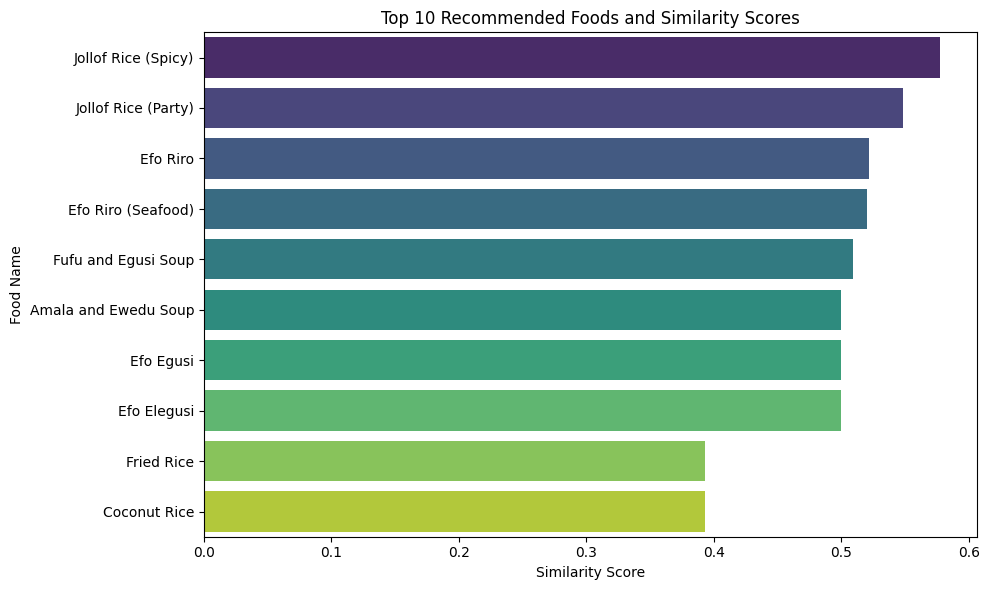

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'recommended_foods' is the DataFrame returned by get_recommendations()
# Make sure to run the get_recommendations cell first to have this DataFrame available

if not recommended_foods.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Similarity_Score', y='Food_Name', data=recommended_foods, palette='viridis')
    plt.title('Top 10 Recommended Foods and Similarity Scores')
    plt.xlabel('Similarity Score')
    plt.ylabel('Food Name')
    plt.tight_layout()
    plt.show()
else:
    print("No recommendations to visualize.")

## Create Recommendation Function

### Subtask:
Develop a function that takes a food item name as input and returns a list of recommended food items based on the cosine similarity matrix.

In [12]:
def get_recommendations(food_name, cosine_sim_matrix=cosine_sim_matrix, df=df):
    """
    Generates food recommendations based on cosine similarity.

    Args:
        food_name (str): The name of the food item to get recommendations for.
        cosine_sim_matrix (np.array): The cosine similarity matrix.
        df (pd.DataFrame): The original DataFrame with food names.

    Returns:
        pd.DataFrame: A DataFrame of recommended food items and their similarity scores.
    """
    # Get the index of the food item that matches the name
    try:
        idx = df[df['Food_Name'] == food_name].index[0]
    except IndexError:
        print(f"Food item '{food_name}' not found in the dataset.")
        return pd.DataFrame() # Return an empty DataFrame if the food is not found

    # Get the pairwise similarity scores for the food item
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort the food items based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar food items (excluding the input food itself)
    sim_scores = sim_scores[1:11]

    # Get the food indices
    food_indices = [i[0] for i in sim_scores]

    # Get the food names and similarity scores
    recommendations = df['Food_Name'].iloc[food_indices]
    similarity_scores = [i[1] for i in sim_scores]

    # Create a DataFrame of recommendations
    recommendations_df = pd.DataFrame({'Food_Name': recommendations, 'Similarity_Score': similarity_scores})

    return recommendations_df

# Example usage: Get recommendations for 'Jollof Rice'
# Replace 'Jollof Rice' with a food name from your dataset to test
recommended_foods = get_recommendations('Jollof Rice')

# Display the recommendations
if not recommended_foods.empty:
    print("Recommendations for Jollof Rice:")
    display(recommended_foods)

Recommendations for Jollof Rice:


,Food_Name,Similarity_Score
57,Jollof Rice (Spicy),0.577413
59,Jollof Rice (Party),0.548079
41,Efo Riro,0.521834
42,Efo Riro (Seafood),0.519640
51,Fufu and Egusi Soup,0.509097
12,Amala and Ewedu Soup,0.500000
38,Efo Egusi,0.500000
39,Efo Elegusi,0.500000
50,Fried Rice,0.393045
32,Coconut Rice,0.392973


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity matrix
cosine_sim_matrix = cosine_similarity(df_combined_features)

# Display the shape of the cosine similarity matrix
print("Shape of cosine similarity matrix:", cosine_sim_matrix.shape)

# Display the first few rows of the cosine similarity matrix (optional)
# display(pd.DataFrame(cosine_sim_matrix).head())

Shape of cosine similarity matrix: (109, 109)


## Define Recommendation Model

### Subtask:
Define the recommendation model, likely using a similarity metric like cosine similarity on the combined feature set.

## Combine Features

### Subtask:
Combine the TF-IDF features and the one-hot encoded categorical features into a single DataFrame.

In [10]:
# Combine TF-IDF features with the one-hot encoded DataFrame
# Ensure that the indices are aligned before combining
df_combined_features = pd.concat([df_encoded.drop(columns=['Food_Name', 'Main_Ingredients', 'Description']), tfidf_df], axis=1)

# Display the shape of the combined feature DataFrame
print("Shape of combined feature DataFrame:", df_combined_features.shape)

# Display the first few rows of the combined feature DataFrame (optional)
# display(df_combined_features.head())

Shape of combined feature DataFrame: (109, 317)


## Define the Problem and Use Case

### Subtask:
Based on the dataset and the challenge description, precisely define the real-world problem the recommendation system will solve and its specific use case.

**Reasoning**:
To build a relevant and impactful recommendation system, we need to clearly define the problem we are addressing and how the system will be used in a real-world scenario.

**Problem Definition**:
Based on the available data (Food Name, Main Ingredients, Description, Food Health, Food Class, Region, Spice Level, Price Range), the problem we can address is to build a system that recommends Nigerian food dishes to users of a food delivery app. The goal is to improve user experience by suggesting dishes they are likely to enjoy, potentially increasing engagement and sales on the platform.

**Use Case**:
The primary use case is within a Nigerian food delivery application. When a user is browsing the app, the system will provide personalized food recommendations based on their past orders, preferences (if available), and potentially the characteristics of the food items themselves (content-based filtering). This can be presented as a "Recommended for You" section on the app's home screen or as suggestions when the user is exploring different food categories.

**Specific Innovation/Relevance**:
Given the dataset's features, a potential innovation could be incorporating the 'Food_Health' and 'Spice_Level' attributes into the recommendation logic. This allows for recommendations that not only align with taste preferences but also dietary considerations (healthy options) and spice tolerance. This adds a layer of value beyond basic item similarity and can address real-world user needs related to health and dietary restrictions.

**Reasoning**:
The previous attempt to load the data failed because the file 'NigerianFoods.csv' was not found in the expected locations. I will try to load the data again, assuming the dataset is available as 'NigerianFoods.csv' in the default content directory, as indicated by the problem description, and include the error handling for `FileNotFoundError` to ensure the task fails gracefully if the file is still not found.

